In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [31]:
df=pd.read_csv(r"C:\Users\sidha\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [33]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 1.What is the overall churn rate?

In [35]:
overall_churn_rate = data["ChurnFlag"].mean()
print(f"Overall churn rate: {overall_churn_rate:.2%}\n")

Overall churn rate: 26.54%



# 2.Which customer segments have the highest churn?

In [36]:
segment_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PaperlessBilling"]
for col in segment_cols:
    churn_by_segment = data.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False)
    print(f"Churn by {col}:")
    print((churn_by_segment * 100).round(2).astype(str) + "%")
    print()

Churn by gender:
gender
Female    26.92%
Male      26.16%
Name: ChurnFlag, dtype: object

Churn by SeniorCitizen:
SeniorCitizen
1    41.68%
0    23.61%
Name: ChurnFlag, dtype: object

Churn by Partner:
Partner
No     32.96%
Yes    19.66%
Name: ChurnFlag, dtype: object

Churn by Dependents:
Dependents
No     31.28%
Yes    15.45%
Name: ChurnFlag, dtype: object

Churn by PaperlessBilling:
PaperlessBilling
Yes    33.57%
No     16.33%
Name: ChurnFlag, dtype: object



# 3.Does contract type affect churn?

Churn rate by contract type:
Contract
Month-to-month    42.71%
One year          11.27%
Two year           2.83%
Name: ChurnFlag, dtype: object

Overall churn rate: 26.54%


C:\Users\sidha\AppData\Local\Temp\ipykernel_8328\1488768642.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_churn.index, y=contract_churn.values, palette="Blues_r")


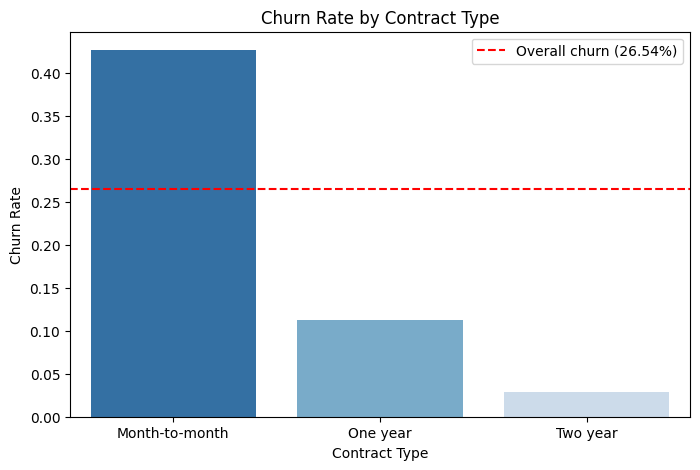

In [37]:
print("Churn rate by contract type:")
print((contract_churn * 100).round(2).astype(str) + "%")
print(f"\nOverall churn rate: {overall_churn_rate:.2%}")

plt.figure(figsize=(8, 5))
sns.barplot(x=contract_churn.index, y=contract_churn.values, palette="Blues_r")
plt.axhline(overall_churn_rate, color="red", linestyle="--", label=f"Overall churn ({overall_churn_rate:.2%})")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.legend()
plt.show()


# 4.Which payment method has the highest churn?

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Total Customers: 7043
Active Customers: 5174
Churned Customers: 1869
Churn Rate %: 26.54%
Average Monthly Revenue: $64.76
Revenue Lost (Monthly): $139,130.85
Revenue Lost (Annualized): $1,669,570.20
Average Tenure: 32.37 months
Customer Lifetime Value (basic): $2,096.41

Average Monthly Charge by Churn Status:
ChurnFlag
Active     61.27
Churned    74.44
Name: MonthlyCharges, dtype: float64 

Revenue by gender:
gender
Male      228684.2
Female    227432.4
Name: MonthlyCharges, dtype: float64 

Revenue by SeniorCitizen:
SeniorCitizen
0    364961.75
1     91154.85
Name: MonthlyCharges, dtype: float64 

Revenue by Partner:
Partner
Yes    230574.85
No     225541.75
Name: MonthlyCharges, dtype: float64 

Revenue by Dependents:
Dependents
No     330524.85
Yes    125591.75
Name: MonthlyCharges, dtype: float64 

Revenue by Contract Type:
Contract
Month-to-month    257294.15
Two year          103005.85
One year           95816.60
Name: MonthlyCharges, dtype: float64 

Churn rate by OnlineSecurit

C:\Users\sidha\AppData\Local\Temp\ipykernel_8328\1006575888.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x=col, y="ChurnFlag", ax=ax, palette="Blues_r")
C:\Users\sidha\AppData\Local\Temp\ipykernel_8328\1006575888.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x=col, y="ChurnFlag", ax=ax, palette="Blues_r")
C:\Users\sidha\AppData\Local\Temp\ipykernel_8328\1006575888.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x=col, y="ChurnFlag", ax=ax, palette="Blues_r")
C:\Users\sidha\AppData\Local\Te

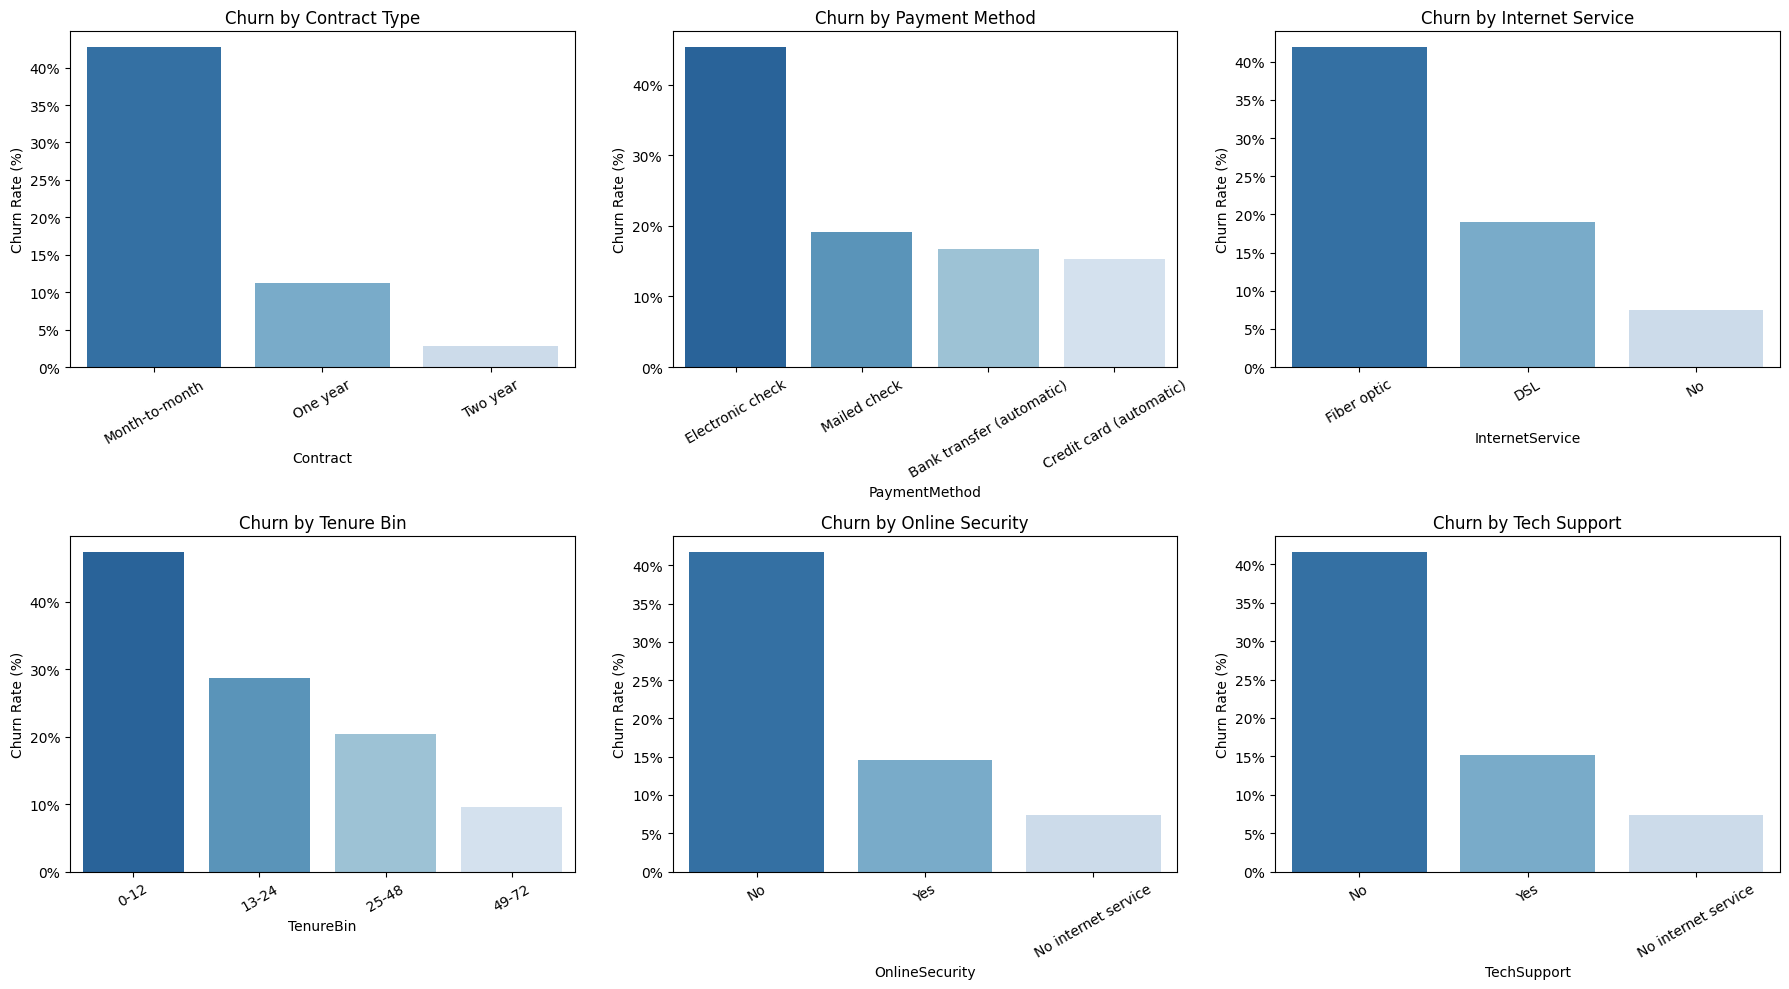

In [40]:
# Reusable working copy
work_df = data.copy()
work_df["MonthlyCharges"] = pd.to_numeric(work_df["MonthlyCharges"], errors="coerce")
work_df["TotalCharges"] = pd.to_numeric(work_df["TotalCharges"], errors="coerce")

overall_rate = globals().get("overall_churn_rate", globals().get("Overall_Churn_Rate", work_df["ChurnFlag"].mean()))
active = work_df[work_df["ChurnFlag"] == 0]
churned = work_df[work_df["ChurnFlag"] == 1]

# KPI summary
revenue_lost_monthly = churned["MonthlyCharges"].sum()
revenue_lost_annual = revenue_lost_monthly * 12
avg_monthly_by_status = work_df.groupby("ChurnFlag")["MonthlyCharges"].mean().rename({0: "Active", 1: "Churned"})
avg_tenure = work_df["tenure"].mean()
clv_basic = work_df["MonthlyCharges"].mean() * avg_tenure

print(f"Total Customers: {work_df.shape[0]}")
print(f"Active Customers: {len(active)}")
print(f"Churned Customers: {len(churned)}")
print(f"Churn Rate %: {overall_rate:.2%}")
print(f"Average Monthly Revenue: ${work_df['MonthlyCharges'].mean():.2f}")
print(f"Revenue Lost (Monthly): ${revenue_lost_monthly:,.2f}")
print(f"Revenue Lost (Annualized): ${revenue_lost_annual:,.2f}")
print(f"Average Tenure: {avg_tenure:.2f} months")
print(f"Customer Lifetime Value (basic): ${clv_basic:,.2f}\n")

print("Average Monthly Charge by Churn Status:")
print(avg_monthly_by_status.round(2), "\n")

# Revenue by customer type
customer_type_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]
for col in customer_type_cols:
    rev = work_df.groupby(col)["MonthlyCharges"].sum().sort_values(ascending=False)
    print(f"Revenue by {col}:")
    print(rev.round(2), "\n")

# Contract revenue
contract_revenue = work_df.groupby("Contract")["MonthlyCharges"].sum().sort_values(ascending=False)
print("Revenue by Contract Type:")
print(contract_revenue.round(2), "\n")

# Churn behavior insights
behavior_cols = ["OnlineSecurity", "TechSupport", "SeniorCitizen", "Dependents", "PaperlessBilling", "InternetService", "PaymentMethod"]
for col in behavior_cols:
    churn_rate = work_df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False)
    print(f"Churn rate by {col}:")
    print((churn_rate * 100).round(2).astype(str) + "%", "\n")

# Customers who pay more and leave early
q75_charge = work_df["MonthlyCharges"].quantile(0.75)
q25_tenure = work_df["tenure"].quantile(0.25)
high_charge_low_tenure = churned[(churned["MonthlyCharges"] >= q75_charge) & (churned["tenure"] <= q25_tenure)]
print(f"High-charge, low-tenure churned customers: {len(high_charge_low_tenure)}")
print(high_charge_low_tenure[["customerID", "Contract", "PaymentMethod", "tenure", "MonthlyCharges", "TotalCharges"]].head(10).to_string(index=False), "\n")

# Add-on services and bundles
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
work_df["AddOnCount"] = work_df[addon_cols].apply(
    lambda row: sum(val not in ["No", "No internet service"] for val in row),
    axis=1
)

addon_churn = work_df.groupby("AddOnCount")["ChurnFlag"].mean().sort_index()
print("Churn rate by number of add-on services:")
print((addon_churn * 100).round(2).astype(str) + "%", "\n")

work_df["ServiceBundle"] = work_df[addon_cols].astype(str).agg(" | ".join, axis=1)
bundle_table = (
    work_df.groupby("ServiceBundle")
    .agg(Customers=("customerID", "size"), ChurnRate=("ChurnFlag", "mean"))
    .query("Customers >= 50")
    .sort_values(["ChurnRate", "Customers"], ascending=[True, False])
)
print("Lowest-churn service bundles (min 50 customers):")
print(bundle_table.head(10).assign(ChurnRate=lambda x: (x["ChurnRate"] * 100).round(2)).to_string(), "\n")

# Internet and contract stability
internet_churn_tbl = work_df.groupby("InternetService")["ChurnFlag"].mean().sort_values(ascending=False)
print("Churn rate by Internet Service:")
print((internet_churn_tbl * 100).round(2).astype(str) + "%", "\n")

# High-risk active customers
risk = active.copy()
risk["risk_score"] = 0
risk["risk_score"] += (risk["Contract"].eq("Month-to-month")).astype(int) * 2
risk["risk_score"] += (risk["InternetService"].eq("Fiber optic")).astype(int)
risk["risk_score"] += (risk["PaymentMethod"].eq("Electronic check")).astype(int)
risk["risk_score"] += (risk["OnlineSecurity"].isin(["No", "No internet service"])).astype(int)
risk["risk_score"] += (risk["TechSupport"].isin(["No", "No internet service"])).astype(int)
risk["risk_score"] += (risk["PaperlessBilling"].eq("Yes")).astype(int) * 0.5
risk["risk_score"] += (risk["SeniorCitizen"].eq(1)).astype(int) * 0.5
risk["risk_score"] += (risk["tenure"] <= q25_tenure).astype(int)
risk["risk_score"] += (risk["MonthlyCharges"] >= q75_charge).astype(int)

top_risk = risk.sort_values(["risk_score", "MonthlyCharges", "tenure"], ascending=[False, False, True])
print("Top high-risk active customers:")
print(top_risk[["customerID", "Contract", "InternetService", "PaymentMethod", "tenure", "MonthlyCharges", "risk_score"]].head(10).to_string(index=False), "\n")

# Simple dashboard plots
fig2, ax_arr = plt.subplots(2, 3, figsize=(18, 10))

plot_specs = [
    ("Contract", "Churn by Contract Type"),
    ("PaymentMethod", "Churn by Payment Method"),
    ("InternetService", "Churn by Internet Service"),
    ("TenureBin", "Churn by Tenure Bin"),
    ("OnlineSecurity", "Churn by Online Security"),
    ("TechSupport", "Churn by Tech Support"),
]

for ax, (col, title) in zip(ax_arr.ravel(), plot_specs):
    tmp = work_df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=tmp, x=col, y="ChurnFlag", ax=ax, palette="Blues_r")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.tight_layout()
plt.show()